# **Predicting Used Car Selling Price Using Machine Learning**

Team members:

1.   Heng-Jui Chu
2.   Simbarashe Mpofu
3.   Simbarashe Simbangegavi

## **Dataset and Github**


### **Dataset**

[Used Car Price Dataset (Kaggle)](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data)



### **Github**

[Machine Learning Project GitHub](https://github.com/Simba-gwu/Machine_learning_project)

## **Introduction**


Nowadays, many people use online platforms to buy and sell used cars, and pricing is always an important issue. The price of a used car can be affected by many factors, such as brand, mileage, age, and condition. Some websites, like CarMax, provide estimated prices, but we usually do not know how accurate these estimates are or how they are calculated. Therefore, we wonder: can a machine learning model predict used car prices more accurately than existing online estimation tools?

The motivation for this project comes from the need for more reliable and transparent pricing. Buyers want to ensure they are not paying too much, while sellers want to set a reasonable price to attract buyers. However, current online tools do not clearly explain their prediction processes, which makes it difficult to fully trust them. Therefore, building a machine learning model based on real data can be a better way to understand how prices are determined.

In this project, we will use a used car dataset to train a machine learning model and evaluate its performance. The main questions we want to answer are:

1. How well can a machine learning model predict used car prices?
2. What factors have the biggest impact on car prices?

Additionally, this project aims to provide a better understanding of used car pricing and demonstrate how machine learning can be used as a useful tool for price prediction.

## **Experiment**

In [101]:
from google.colab import drive
import sys

# Mount Google Drive
drive.mount('/content/drive')

# Get the absolute path of the current folder
abspath_curr = '/content/drive/My Drive/ML project/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
import os
from pathlib import Path



In [103]:
print(os.listdir(abspath_curr))


['result', 'vehicles.csv', 'test_predictions_dollars.csv', 'test_results_with_info.csv', 'test_results_full.csv']


**Warning**

In [104]:
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

**Matplotlib**

In [105]:
import matplotlib.pyplot as plt
%matplotlib inline

# Set matplotlib sizes
plt.rc('font', size=20)
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize=20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('legend', fontsize=20)
plt.rc('figure', titlesize=20)

**TensorFlow**

In [106]:
# The magic below allows us to use tensorflow version 2.x
%tensorflow_version 2.x
import tensorflow as tf
from tensorflow import keras

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


**Random seed**

In [107]:
# The random seed
random_seed = 42

# Set random seed in tensorflow
tf.random.set_seed(random_seed)

# Set random seed in numpy
import numpy as np
np.random.seed(random_seed)

**Import tools**

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap


## **Data Preprocessing**

**Loading the data**

In [109]:
df_raw_train = pd.read_csv(abspath_curr + '/vehicles.csv',
                           header=0)

# Make a copy of df_raw_train
df_train = df_raw_train.copy(deep=True)

# Get the name of the target
target = 'price'


### **Remove obvious outliers**

In [110]:

df_train = df_train[df_train['price'].notna()]
df_train = df_train[(df_train['price'] >= 500) & (df_train['price'] <= 100000)]


df_train = df_train[df_train['year'].notna()]
df_train = df_train[(df_train['year'] >= 1980) & (df_train['year'] <= 2022)]


df_train = df_train[(df_train['odometer'].isna()) | ((df_train['odometer'] >= 0) & (df_train['odometer'] <= 300000))]

df_train = df_train.reset_index(drop=True)

print("After filtering:")
print(df_train[['price', 'year', 'odometer']].describe())

After filtering:
               price           year       odometer
count  372595.000000  372595.000000  370563.000000
mean    19147.108963    2012.027877   92827.738484
std     14293.013909       6.373614   61985.365490
min       500.000000    1980.000000       0.000000
25%      7885.000000    2008.000000   39000.000000
50%     15950.000000    2013.000000   88361.000000
75%     27990.000000    2017.000000  136000.000000
max    100000.000000    2022.000000  300000.000000


In [111]:
# Print the dimension of df_train
pd.DataFrame([[df_train.shape[0], df_train.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,372595,26


In [112]:
# Print the first 5 rows of df_train
df_train.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7316814884,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,...,NaN,pickup,white,https://images.craigslist.org/00R0R_lwWjXSEWNa...,Carvana is the safer way to buy a car During t...,NaN,al,32.590,-85.4800,2021-05-04T12:31:18-0500
1,7316814758,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,...,NaN,pickup,blue,https://images.craigslist.org/00R0R_lwWjXSEWNa...,Carvana is the safer way to buy a car During t...,NaN,al,32.590,-85.4800,2021-05-04T12:31:08-0500
2,7316814989,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,...,NaN,pickup,red,https://images.craigslist.org/01212_jjirIWa0y0...,Carvana is the safer way to buy a car During t...,NaN,al,32.590,-85.4800,2021-05-04T12:31:25-0500
3,7316743432,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,...,NaN,pickup,red,https://images.craigslist.org/00x0x_1y9kIOzGCF...,Carvana is the safer way to buy a car During t...,NaN,al,32.590,-85.4800,2021-05-04T10:41:31-0500
4,7316356412,https://auburn.craigslist.org/cto/d/auburn-uni...,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,...,full-size,truck,black,https://images.craigslist.org/00404_l4loxHvdQe...,2013 F-150 XLT V6 4 Door. Good condition. Leve...,NaN,al,32.592,-85.5189,2021-05-03T14:02:03-0500


### **Distribution**

#### **Price distribution**

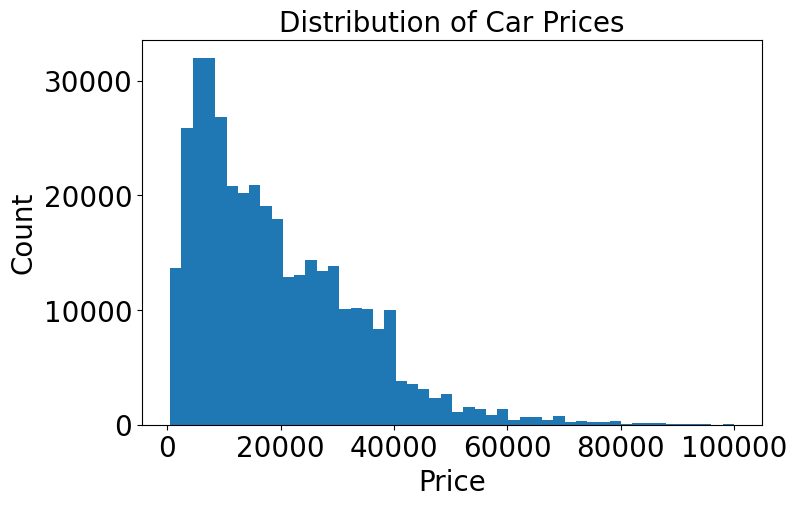

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_train['price'], bins=50)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

The distribution of car prices is right-skewed, with most cars concentrated at lower price levels and only a few high-priced vehicles. This indicates that expensive cars are rare in the dataset.

#### **Year vs Price**

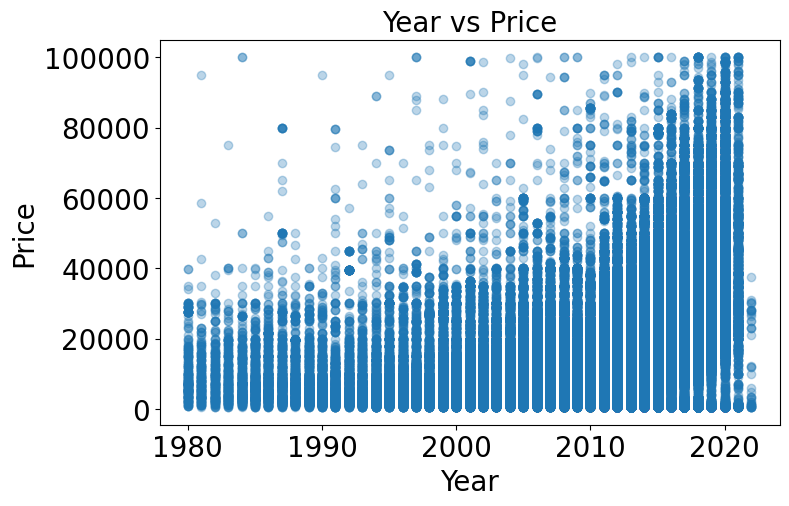

In [114]:
plt.figure(figsize=(8,5))
plt.scatter(df_train['year'], df_train['price'], alpha=0.3)
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Year vs Price')
plt.show()

There is a clear positive relationship between year and price, where newer cars tend to have higher prices, indicating that age is an important factor in car valuation.

#### **Odometer vs Price**

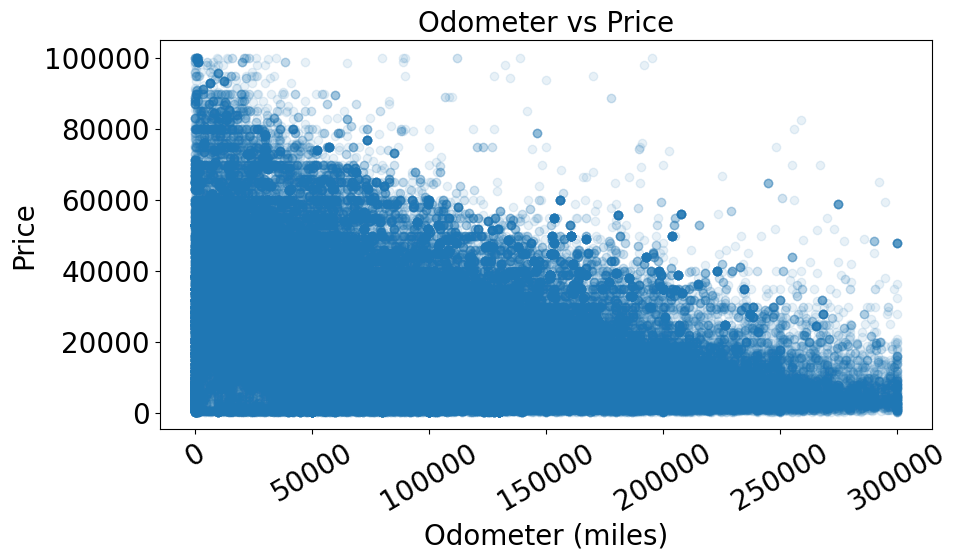

In [115]:
plt.figure(figsize=(10,6))

plt.scatter(df_train['odometer'], df_train['price'], alpha=0.1)

plt.xlabel('Odometer (miles)')
plt.ylabel('Price')
plt.title('Odometer vs Price')

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

There is a clear negative relationship between mileage and price, where cars with higher mileage tend to have lower prices.

### **Removing unwanted columns**

In [116]:
# Create a list of all columns that won't help with price prediction
cols_to_drop = [
     'url', 'region_url', 'VIN', 'image_url',
    'description', 'county','size', 'lat', 'long'
]

# Drop them all at once
df_train = df_train.drop(columns=cols_to_drop)

# Double-check the remaining columns
print(df_train.columns)

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state', 'posting_date'],
      dtype='object')


In [117]:
# Print the first 5 rows of df_train
df_train.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
0,7316814884,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,NaN,pickup,white,al,2021-05-04T12:31:18-0500
1,7316814758,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,NaN,pickup,blue,al,2021-05-04T12:31:08-0500
2,7316814989,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,NaN,pickup,red,al,2021-05-04T12:31:25-0500
3,7316743432,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,NaN,pickup,red,al,2021-05-04T10:41:31-0500
4,7316356412,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,2021-05-03T14:02:03-0500


### **Splitting the data**

The code below shows how to divide the training data into training (60%) ,validation (20%) and testing (20%).

In [118]:
from sklearn.model_selection import train_test_split

# Divide the training data into training (60%) , temp (40%)
df_train, df_temp = train_test_split(df_train, train_size=0.6, random_state=random_seed)

# Second split: split temp into validation and test (20% each)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=random_seed)

# Reset the index
df_train, df_val , df_test = df_train.reset_index(drop=True), df_val.reset_index(drop=True) , df_test.reset_index(drop=True)

In [119]:
# Print the dimension of df_train
pd.DataFrame([[df_train.shape[0], df_train.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,223557,17


In [120]:
# Print the dimension of df_val
pd.DataFrame([[df_val.shape[0], df_val.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,74519,17


In [121]:
# Print the dimension of df_test
pd.DataFrame([[df_test.shape[0], df_test.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,74519,17


### **Identifying uncommon variables**

The code below shows how to find common variables between the training, validation and test data.

In [122]:
def common_var_checker(df_train, df_val, df_test, target):
    """
    The common variables checker

    Parameters
    ----------
    df_train : the dataframe of training data
    df_val : the dataframe of validation data
    df_test : the dataframe of test data
    target : the name of the target

    Returns
    ----------
    The dataframe of common variables between the training, validation and test data
    """

    # Get the dataframe of common variables between the training, validation and test data
    df_common_var = pd.DataFrame(np.intersect1d(np.intersect1d(df_train.columns, df_val.columns), np.union1d(df_test.columns, [target])),
                                 columns=['common var'])

    return df_common_var

In [123]:
# Call common_var_checker
#
df_common_var = common_var_checker(df_train, df_val, df_test, target)

# Print df_common_var
df_common_var

,common var
0,condition
1,cylinders
2,drive
3,fuel
4,id
5,manufacturer
6,model
7,odometer
8,paint_color
9,posting_date


The code below shows how to find features in the training data but not in the validation or test data.

In [124]:
# Get the features in the training data but not in the validation or test data
uncommon_feature_train_not_val_test = np.setdiff1d(df_train.columns, df_common_var['common var'])

# Print the uncommon features
pd.DataFrame(uncommon_feature_train_not_val_test, columns=['uncommon feature'])

,uncommon feature


The code below shows how to find the features in the validation data but not in the training or test data.

In [125]:
# Get the features in the validation data but not in the training or test data
uncommon_feature_val_not_train_test = np.setdiff1d(df_val.columns, df_common_var['common var'])

# Print the uncommon features
pd.DataFrame(uncommon_feature_val_not_train_test, columns=['uncommon feature'])

,uncommon feature


The code below shows how to find the features in the test data but not in the training or validation data.

In [126]:
# Get the features in the test data but not in the training or validation data
uncommon_feature_test_not_train_val = np.setdiff1d(df_test.columns, df_common_var['common var'])

# Print the uncommon features
pd.DataFrame(uncommon_feature_test_not_train_val, columns=['uncommon feature'])

,uncommon feature


### **Removing uncommon features**

In [127]:
# Remove the uncommon features from the training data
df_train = df_train.drop(columns=uncommon_feature_train_not_val_test)

# Print the first 5 rows of df_train
df_train.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
0,7315091925,columbia / jeff city,10000,2006.0,chevrolet,1500,good,8 cylinders,gas,129000.0,salvage,automatic,rwd,van,white,mo,2021-04-30T18:26:25-0500
1,7303624197,harrisburg,12500,2021.0,chevrolet,trailblazer,NaN,NaN,other,2773.0,salvage,automatic,fwd,SUV,NaN,pa,2021-04-08T10:43:17-0400
2,7314957709,raleigh / durham / CH,8500,2007.0,ford,mustang,excellent,8 cylinders,gas,267077.0,clean,manual,rwd,NaN,blue,nc,2021-04-30T15:09:12-0400
3,7311319486,cleveland,9995,2009.0,mercedes-benz,m-class,NaN,NaN,gas,181774.0,clean,automatic,NaN,other,black,oh,2021-04-23T10:16:18-0400
4,7316526944,charlotte,7800,2006.0,honda,ridgeline rtl 4wd,good,6 cylinders,gas,176000.0,clean,automatic,4wd,pickup,red,nc,2021-05-03T20:28:36-0400


In [128]:
# Remove the uncommon features from the validation data
df_val = df_val.drop(columns=uncommon_feature_val_not_train_test)

# Print the first 5 rows of df_val
df_val.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
0,7316727650,columbus,7850,2008.0,audi,q7,NaN,8 cylinders,gas,0.0,clean,automatic,4wd,SUV,blue,oh,2021-05-04T11:14:53-0400
1,7313619428,western massachusetts,1500,1988.0,ford,bronco,fair,6 cylinders,gas,140000.0,clean,automatic,4wd,NaN,NaN,ma,2021-04-27T19:54:28-0400
2,7316152351,denver,4995,2006.0,toyota,sienna,good,6 cylinders,gas,189921.0,clean,automatic,fwd,mini-van,green,co,2021-05-03T07:35:09-0600
3,7301959626,la salle co,22990,2020.0,hyundai,sonata se sedan 4d,good,NaN,gas,3066.0,clean,other,fwd,sedan,blue,il,2021-04-05T05:50:28-0500
4,7314712553,akron / canton,6995,2013.0,nissan,sentra,NaN,4 cylinders,gas,118164.0,clean,automatic,fwd,sedan,grey,oh,2021-04-30T06:24:53-0400


In [129]:
# Remove the uncommon features from the test data
df_test = df_test.drop(columns=uncommon_feature_test_not_train_val)

# Print the first 5 rows of df_test
df_test.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
0,7308316620,indianapolis,49990,2019.0,toyota,4runner trd pro sport,good,6 cylinders,gas,25164.0,clean,other,4wd,SUV,blue,in,2021-04-17T13:00:53-0400
1,7316546652,SF bay area,36900,2020.0,hyundai,kona ev ultimate,good,NaN,electric,5232.0,clean,automatic,fwd,other,white,ca,2021-05-03T18:20:39-0700
2,7313771441,albuquerque,5500,1998.0,chevrolet,2500,NaN,NaN,gas,154000.0,clean,automatic,NaN,NaN,NaN,nm,2021-04-28T07:21:19-0600
3,7313904291,erie,26990,2016.0,ford,f150 regular cab xl pickup,good,6 cylinders,gas,14230.0,clean,other,NaN,pickup,black,pa,2021-04-28T13:12:25-0400
4,7313473158,flint,9900,2006.0,jeep,wrangler,NaN,NaN,gas,154206.0,clean,automatic,NaN,NaN,NaN,mi,2021-04-27T15:06:41-0400


### **Handling identifiers**

**Combining the training, validation and test data**

The code below shows how to combine the training, validation and test da

In [130]:
# Combine df_train, df_val and df_test
df = pd.concat([df_train, df_val, df_test], sort=False)

**Identifying identifiers**

The code below shows how to find identifiers from data.

In [131]:
def id_checker(df, dtype='float'):
    """
    The identifier checker

    Parameters
    ----------
    df : dataframe
    dtype : the data type identifiers cannot have, 'float' by default
            i.e., if a feature has this data type, it cannot be an identifier

    Returns
    ----------
    The dataframe of identifiers
    """

    # Get the dataframe of identifiers
    df_id = df[[var for var in df.columns
                # If the data type is not dtype
                if (df[var].dtype != dtype
                    # If the value is unique for each sample
                    and df[var].nunique(dropna=True) == df[var].notnull().sum())]]

    return df_id

In [132]:
# Call id_checker on df
# See the implementation in pmlm_utilities.ipynb
df_id = id_checker(df)

# Print the first 5 rows of df_id
df_id.head()

,id
0,7315091925
1,7303624197
2,7314957709
3,7311319486
4,7316526944


**Removing identifiers**

The code below shows how to remove identifiers from data.

In [133]:
import numpy as np

# Remove identifiers from df_train
df_train.drop(columns=np.intersect1d(df_id.columns, df_train.columns), inplace=True)

# Remove identifiers from df_val
df_val.drop(columns=np.intersect1d(df_id.columns, df_val.columns), inplace=True)

# Remove identifiers from df_test
df_test.drop(columns=np.intersect1d(df_id.columns, df_test.columns), inplace=True)

**Handling missing data**

**Combining the training, validation and test data**

The code below shows how to combine the training, validation and test data.

In [134]:
# Combine df_train, df_val and df_test
df = pd.concat([df_train, df_val, df_test], sort=False)

**Identifying missing values**

The code below shows how to find variables with NaN, their proportion of NaN and data type.

In [135]:
def nan_checker(df):
    """
    The NaN checker

    Parameters
    ----------
    df : the dataframe

    Returns
    ----------
    The dataframe of variables with NaN, their proportion of NaN and data type
    """

    # Get the dataframe of variables with NaN, their proportion of NaN and data type
    df_nan = pd.DataFrame([[var, df[var].isna().sum() / df.shape[0], df[var].dtype]
                           for var in df.columns if df[var].isna().sum() > 0],
                          columns=['var', 'proportion', 'dtype'])

    # Sort df_nan in accending order of the proportion of NaN
    df_nan = df_nan.sort_values(by='proportion', ascending=False).reset_index(drop=True)

    return df_nan

In [136]:
# Call nan_checker on df
# See the implementation in pmlm_utilities.ipynb
df_nan = nan_checker(df)

# Print df_nan
df_nan

,var,proportion,dtype
0,cylinders,0.411254,object
1,condition,0.378269,object
2,drive,0.302116,object
3,paint_color,0.287862,object
4,type,0.210403,object
5,manufacturer,0.032115,object
6,title_status,0.017931,object
7,model,0.009635,object
8,fuel,0.006213,object
9,odometer,0.005454,float64


In [137]:
# Print the unique data type of variables with NaN
pd.DataFrame(df_nan['dtype'].unique(), columns=['dtype'])

,dtype
0,object
1,float64


In [138]:
df_miss = df_nan[df_nan['dtype'] == 'object'].reset_index(drop=True)
df_miss

,var,proportion,dtype
0,cylinders,0.411254,object
1,condition,0.378269,object
2,drive,0.302116,object
3,paint_color,0.287862,object
4,type,0.210403,object
5,manufacturer,0.032115,object
6,title_status,0.017931,object
7,model,0.009635,object
8,fuel,0.006213,object
9,transmission,0.004670,object


In [139]:
df_miss_num = df_nan[df_nan['dtype'] == 'float64'].reset_index(drop=True)
df_miss_num

,var,proportion,dtype
0,odometer,0.005454,float64


**Separating the training, validation and test data**

The code below shows how to separate the training, validation and test data.


In [140]:
#Separating the training data
df_train = df.iloc[:df_train.shape[0], :]

# Separating the validation data
df_val = df.iloc[df_train.shape[0]:df_train.shape[0] + df_val.shape[0], :]

# Separating the test data
df_test = df.iloc[df_train.shape[0] + df_val.shape[0]:, :]

In [141]:
# Print the dimension of df_train
pd.DataFrame([[df_train.shape[0], df_train.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,223557,16


In [142]:
# Print the dimension of df_val
pd.DataFrame([[df_val.shape[0], df_val.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,74519,16


In [143]:
# Print the dimension of df_test
pd.DataFrame([[df_test.shape[0], df_test.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,74519,16


In [144]:
# Print the dimension of df_train
pd.DataFrame([[df_train.shape[0], df_train.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,223557,16


Handling missing values in Cylinders by changing it to a float and imouting the missing with median

In [145]:
# --- 1. HANDLE CYLINDERS (Numerical + Flag) ---
# Extract digits only (e.g., "8 cylinders" -> 8.0)
df_train['cylinders'] = df_train['cylinders'].str.extract('(\d+)').astype(float)
df_val['cylinders'] = df_val['cylinders'].str.extract('(\d+)').astype(float)
df_test['cylinders'] = df_test['cylinders'].str.extract('(\d+)').astype(float)

# Create the 'unknown' flag BEFORE filling the NaNs
# This preserves the "signal" that the seller didn't provide info
df_train['cylinders_unknown'] = df_train['cylinders'].isnull().astype(int)
df_val['cylinders_unknown'] = df_val['cylinders'].isnull().astype(int)
df_test['cylinders_unknown'] = df_test['cylinders'].isnull().astype(int)

# Fill the NaNs with the median (usually 6.0)
cyl_median_train = df_train['cylinders'].median()
cyl_median_val = df_val['cylinders'].median()
cyl_median_test = df_test['cylinders'].median()
df_train['cylinders'] = df_train['cylinders'].fillna(cyl_median_train)
df_val['cylinders'] = df_val['cylinders'].fillna(cyl_median_train)
df_test['cylinders'] = df_test['cylinders'].fillna(cyl_median_train)

Hnadling missing values by dropping rows from columns with few percentage of missing values

In [146]:
vars_to_drop_rows = ['model', 'fuel', 'transmission', 'posting_date','cylinders']

# 2. Apply your logic using inplace=False
if len(vars_to_drop_rows) > 0:
    # We must re-assign the variable because inplace=False returns a NEW dataframe
    df_train = df_train.dropna(subset=np.intersect1d(vars_to_drop_rows, df_train.columns),
                               inplace=False)

    df_val = df_val.dropna(subset=np.intersect1d(vars_to_drop_rows, df_val.columns),
                             inplace=False)

    df_test = df_test.dropna(subset=np.intersect1d(vars_to_drop_rows, df_test.columns),
                              inplace=False)

# 3. Quick check of the new row count
print(f"Cleaned Train rows: {df_train.shape[0]}")

Cleaned Train rows: 219057


In [147]:
# Print the dimension of df_train
pd.DataFrame([[df_train.shape[0], df_train.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,219057,17


In [148]:
df = pd.concat([df_train, df_val, df_test], sort=False)

In [149]:
# Call nan_checker on df
# See the implementation in pmlm_utilities.ipynb
df_nan = nan_checker(df)

# Print df_nan
df_nan

,var,proportion,dtype
0,condition,0.370276,object
1,drive,0.300545,object
2,paint_color,0.285095,object
3,type,0.208689,object
4,manufacturer,0.032199,object
5,title_status,0.016173,object
6,odometer,0.004876,float64


In [150]:
df_miss = df_nan[df_nan['dtype'] == 'object'].reset_index(drop=True)
df_miss

,var,proportion,dtype
0,condition,0.370276,object
1,drive,0.300545,object
2,paint_color,0.285095,object
3,type,0.208689,object
4,manufacturer,0.032199,object
5,title_status,0.016173,object


In [151]:
#Separating the training data
df_train = df.iloc[:df_train.shape[0], :]

# Separating the validation data
df_val = df.iloc[df_train.shape[0]:df_train.shape[0] + df_val.shape[0], :]

# Separating the test data
df_test = df.iloc[df_train.shape[0] + df_val.shape[0]:, :]

**Handling Missing Values by Adding an "Unknown" Category**

In [152]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')

df_train[df_miss['var']] = si.fit_transform(df_train[df_miss['var']])
df_val[df_miss['var']] = si.transform(df_val[df_miss['var']])
df_test[df_miss['var']] = si.transform(df_test[df_miss['var']])

Imputing missing values

The code below shows how to use the median of a numerical feature to impute its missing values.

In [153]:
from sklearn.impute import SimpleImputer

# If there are missing values
if len(df_miss_num['var']) > 0:
    # The SimpleImputer
    si = SimpleImputer(missing_values=np.nan, strategy='median')

    # Impute the variables with missing values in df_train, df_val and df_test
    df_train[df_miss_num['var']] = si.fit_transform(df_train[df_miss_num['var']])
    df_val[df_miss_num['var']] = si.transform(df_val[df_miss_num['var']])
    df_test[df_miss_num['var']] = si.transform(df_test[df_miss_num['var']])

Handling date time variables

Transforming date time variables The code below shows how to transform date time variables into the following 6 datetime types:

year

month

day

hour

minute

second

In [154]:
# Get the date time variables
datetime_vars = ['posting_date']

In [155]:
print(df_train['posting_date'].dtype)
print(df_train['posting_date'].head())

object
0    2021-04-30T18:26:25-0500
1    2021-04-08T10:43:17-0400
2    2021-04-30T15:09:12-0400
3    2021-04-23T10:16:18-0400
4    2021-05-03T20:28:36-0400
Name: posting_date, dtype: object


In [156]:
def datetime_transformer(df, datetime_vars):
    """
    The datetime transformer

    Parameters
    ----------
    df : the dataframe
    datetime_vars : the datetime variables

    Returns
    ----------
    The dataframe where datetime_vars are transformed into the following 6 datetime types:
    year, month, day, hour, minute and second
    """

    # The dictionary with key as datetime type and value as datetime type operator
    dict_ = {'year'   : lambda x : x.dt.year,
             'month'  : lambda x : x.dt.month,
             }

    # Make a copy of df
    df_datetime = df.copy(deep=True)

    # For each variable in datetime_vars
    for var in datetime_vars:
        # Cast the variable to datetime
        df_datetime[var] = pd.to_datetime(df_datetime[var], errors='coerce', utc=True)

        # For each item (datetime_type and datetime_type_operator) in dict_
        for datetime_type, datetime_type_operator in dict_.items():
            # Add a new variable to df_datetime where:
            # the variable's name is var + '_' + datetime_type
            # the variable's values are the ones obtained by datetime_type_operator
            df_datetime[var + '_' + datetime_type] = datetime_type_operator(df_datetime[var])

    # Remove datetime_vars from df_datetime
    df_datetime = df_datetime.drop(columns=datetime_vars)

    return df_datetime

In [157]:
# Call datetime_transformer on df_train
# See the implementation in pmlm_utilities.ipynb
df_train = datetime_transformer(df_train, datetime_vars)

# Print the first 5 rows of df_train
df_train.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,cylinders_unknown,posting_date_year,posting_date_month
0,columbia / jeff city,10000,2006.0,chevrolet,1500,good,8.0,gas,129000.0,salvage,automatic,rwd,van,white,mo,0,2021,4
1,harrisburg,12500,2021.0,chevrolet,trailblazer,Unknown,6.0,other,2773.0,salvage,automatic,fwd,SUV,Unknown,pa,1,2021,4
2,raleigh / durham / CH,8500,2007.0,ford,mustang,excellent,8.0,gas,267077.0,clean,manual,rwd,Unknown,blue,nc,0,2021,4
3,cleveland,9995,2009.0,mercedes-benz,m-class,Unknown,6.0,gas,181774.0,clean,automatic,Unknown,other,black,oh,1,2021,4
4,charlotte,7800,2006.0,honda,ridgeline rtl 4wd,good,6.0,gas,176000.0,clean,automatic,4wd,pickup,red,nc,0,2021,5


In [158]:
# Call datetime_transformer on df_val
# See the implementation in pmlm_utilities.ipynb
df_val = datetime_transformer(df_val, datetime_vars)

# Print the first 5 rows of df_val
df_val.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,cylinders_unknown,posting_date_year,posting_date_month
0,columbus,7850,2008.0,audi,q7,Unknown,8.0,gas,0.0,clean,automatic,4wd,SUV,blue,oh,0,2021,5
1,western massachusetts,1500,1988.0,ford,bronco,fair,6.0,gas,140000.0,clean,automatic,4wd,Unknown,Unknown,ma,0,2021,4
2,denver,4995,2006.0,toyota,sienna,good,6.0,gas,189921.0,clean,automatic,fwd,mini-van,green,co,0,2021,5
3,la salle co,22990,2020.0,hyundai,sonata se sedan 4d,good,6.0,gas,3066.0,clean,other,fwd,sedan,blue,il,1,2021,4
4,akron / canton,6995,2013.0,nissan,sentra,Unknown,4.0,gas,118164.0,clean,automatic,fwd,sedan,grey,oh,0,2021,4


In [159]:
# Call datetime_transformer on df_test
# See the implementation in pmlm_utilities.ipynb
df_test = datetime_transformer(df_test, datetime_vars)

# Print the first 5 rows of df_test
df_test.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,cylinders_unknown,posting_date_year,posting_date_month
0,indianapolis,49990,2019.0,toyota,4runner trd pro sport,good,6.0,gas,25164.0,clean,other,4wd,SUV,blue,in,0,2021,4
1,SF bay area,36900,2020.0,hyundai,kona ev ultimate,good,6.0,electric,5232.0,clean,automatic,fwd,other,white,ca,1,2021,5
2,albuquerque,5500,1998.0,chevrolet,2500,Unknown,6.0,gas,154000.0,clean,automatic,Unknown,Unknown,Unknown,nm,1,2021,4
3,erie,26990,2016.0,ford,f150 regular cab xl pickup,good,6.0,gas,14230.0,clean,other,Unknown,pickup,black,pa,0,2021,4
4,flint,9900,2006.0,jeep,wrangler,Unknown,6.0,gas,154206.0,clean,automatic,Unknown,Unknown,Unknown,mi,1,2021,4


### **Encoding the data**

Combining the training, validation and test data

The code below shows how to combine the training, validation and test data.

In [160]:
# Combine df_train, df_val and df_test
df = pd.concat([df_train, df_val, df_test], sort=False)

# Print the unique data type of variables in df
pd.DataFrame(df.dtypes.unique(), columns=['dtype'])

,dtype
0,object
1,int64
2,float64
3,int32


**Identifying categorical variables**

The code below shows how to find categorical variables (whose data type is dtype) and their number of unique value.

In [161]:
def cat_var_checker(df, dtype='object'):
    """
    The categorical variable checker

    Parameters
    ----------
    df : the dataframe
    dtype : the data type categorical variables should have, 'object' by default
            i.e., if a variable has this data type, it should be a categorical variable

    Returns
    ----------
    The dataframe of categorical variables and their number of unique value
    """

    # Get the dataframe of categorical variables and their number of unique value
    df_cat = pd.DataFrame([[var, df[var].nunique(dropna=False)]
                           # If the data type is dtype
                           for var in df.columns if df[var].dtype == dtype],
                          columns=['var', 'nunique'])

    # Sort df_cat in accending order of the number of unique value
    df_cat = df_cat.sort_values(by='nunique', ascending=False).reset_index(drop=True)

    return df_cat

In [162]:
# Call cat_var_checker on df
# See the implementation in pmlm_utilities.ipynb
df_cat = cat_var_checker(df)

# Print the dataframe
df_cat

,var,nunique
0,model,24332
1,region,404
2,state,51
3,manufacturer,42
4,type,14
5,paint_color,13
6,condition,7
7,title_status,7
8,fuel,5
9,drive,4


#### **Encoding categorical features**

The code below shows how to encode categorical features in the combined data.

In [163]:
high_card_vars = ['model', 'region']


In [164]:
# One-hot-encode the categorical features in the combined data
df = pd.get_dummies(df, columns=np.setdiff1d(df_cat['var'], high_card_vars + [target]))

# Print the first 5 rows of df
df.head()

,region,price,year,model,cylinders,odometer,cylinders_unknown,posting_date_year,posting_date_month,condition_Unknown,...,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon
0,columbia / jeff city,10000,2006.0,1500,8.0,129000.0,0,2021,4,False,...,False,False,False,False,False,False,False,False,True,False
1,harrisburg,12500,2021.0,trailblazer,6.0,2773.0,1,2021,4,True,...,False,False,False,False,False,False,False,False,False,False
2,raleigh / durham / CH,8500,2007.0,mustang,8.0,267077.0,0,2021,4,False,...,False,False,False,False,False,False,False,False,False,False
3,cleveland,9995,2009.0,m-class,6.0,181774.0,1,2021,4,True,...,False,False,False,False,True,False,False,False,False,False
4,charlotte,7800,2006.0,ridgeline rtl 4wd,6.0,176000.0,0,2021,5,False,...,False,False,False,False,False,True,False,False,False,False


**Separating the training, validation and test data**

The code below shows how to separate the training, validation and test data.

In [165]:
# Separating the training data
df_train = df.iloc[:df_train.shape[0], :]

# Separating the validation data
df_val = df.iloc[df_train.shape[0]:df_train.shape[0] + df_val.shape[0], :]

# Separating the test data
df_test = df.iloc[df_train.shape[0] + df_val.shape[0]:, :]

In [166]:
!pip install category_encoders

In [167]:
from category_encoders import TargetEncoder

te = TargetEncoder(cols=['model', 'region'])

df_train[['model', 'region']] = te.fit_transform(
    df_train[['model', 'region']],
    df_train[target]
)

df_val[['model', 'region']] = te.transform(df_val[['model', 'region']])
df_test[['model', 'region']] = te.transform(df_test[['model', 'region']])

In [168]:
# Print the dimension of df_train
pd.DataFrame([[df_train.shape[0], df_train.shape[1]]], columns=['# rows', '# columns'])
df_train.head()

,region,price,year,model,cylinders,odometer,cylinders_unknown,posting_date_year,posting_date_month,condition_Unknown,...,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon
0,25556.815718,10000,2006.0,24063.748372,8.0,129000.0,0,2021,4,False,...,False,False,False,False,False,False,False,False,True,False
1,15651.847619,12500,2021.0,5639.782102,6.0,2773.0,1,2021,4,True,...,False,False,False,False,False,False,False,False,False,False
2,17211.907074,8500,2007.0,17547.933962,8.0,267077.0,0,2021,4,False,...,False,False,False,False,False,False,False,False,False,False
3,14177.279499,9995,2009.0,16896.939687,6.0,181774.0,1,2021,4,True,...,False,False,False,False,True,False,False,False,False,False
4,17559.504438,7800,2006.0,18428.231245,6.0,176000.0,0,2021,5,False,...,False,False,False,False,False,True,False,False,False,False


In [169]:
# Print the dimension of df_val
pd.DataFrame([[df_val.shape[0], df_val.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,73125,155


In [170]:
# Print the dimension of df_test
pd.DataFrame([[df_test.shape[0], df_test.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,73051,155


### **Feature Engineering**

Create car_age

In [171]:
df_train['car_age'] = df_train['posting_date_year'] - df_train['year']
df_val['car_age']   = df_val['posting_date_year'] - df_val['year']
df_test['car_age']  = df_test['posting_date_year'] - df_test['year']

In [172]:
cols_to_drop = ['posting_date_year']

df_train = df_train.drop(columns=cols_to_drop, errors='ignore')
df_val   = df_val.drop(columns=cols_to_drop, errors='ignore')
df_test  = df_test.drop(columns=cols_to_drop, errors='ignore')

**Splitting the feature and target**

The code below shows how to split the feature and target.

In [173]:
# Get the feature matrix
feature_names = np.setdiff1d(df_train.columns, [target])

X_train = df_train[feature_names]
X_val = df_val[feature_names]
X_test = df_test[feature_names]

# Get the target vector
y_train = df_train[target].values
y_val = df_val[target].values
y_test = df_test[target].values

### **Scaling the data**

**Standardization **

The code below shows how to standardize the data.

In [174]:
from sklearn.preprocessing import StandardScaler

# The StandardScaler
ss = StandardScaler()

**Standardizing the features**

The code below shows how to standardize the features.

In [175]:
ss_X = StandardScaler()

# Standardize the training data
X_train = pd.DataFrame(ss_X.fit_transform(X_train), columns=feature_names)

# Standardize the validation data
X_val = pd.DataFrame(ss_X.transform(X_val), columns=feature_names)

# Standardize the test data
X_test = pd.DataFrame(ss_X.transform(X_test), columns=feature_names)


**Standardizing the target**

The code below shows how to standardize the features.

In [176]:
# # Standardize the training data
# y_train = ss.fit_transform(y_train.reshape(-1, 1)).reshape(-1)

# # Standardize the validation data
# y_val = ss.transform(y_val.reshape(-1, 1)).reshape(-1)

# # Standardize the test data
# y_test = ss.transform(y_test.reshape(-1, 1)).reshape(-1)

**Getting the predefined split cross-validator**

In [177]:
from sklearn.model_selection import PredefinedSplit

def get_train_val_ps(X_train, y_train, X_val, y_val):
    """
    Get the:
    feature matrix and target velctor in the combined training and validation data
    target vector in the combined training and validation data
    PredefinedSplit

    Parameters
    ----------
    X_train : the feature matrix in the training data
    y_train : the target vector in the training data
    X_val : the feature matrix in the validation data
    y_val : the target vector in the validation data

    Return
    ----------
    The feature matrix in the combined training and validation data
    The target vector in the combined training and validation data
    PredefinedSplit
    """

    # Combine the feature matrix in the training and validation data
    X_train_val = np.vstack((X_train, X_val))

    # Combine the target vector in the training and validation data
    y_train_val = np.vstack((y_train.reshape(-1, 1), y_val.reshape(-1, 1))).reshape(-1)

    # Get the indices of training and validation data
    train_val_idxs = np.append(np.full(X_train.shape[0], -1), np.full(X_val.shape[0], 0))

    # The PredefinedSplit
    ps = PredefinedSplit(train_val_idxs)

    return X_train_val, y_train_val, ps

## **Hyperparameter Tuning**

In [178]:
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    'sgd': SGDRegressor(random_state=random_seed),
    'lr': LinearRegression(),
    'xgb': XGBRegressor(random_state=random_seed),
    'rf': RandomForestRegressor(random_state=random_seed)
}

**Creating the dictionary of the pipelines**

**In the dictionary:**

the key is the acronym of the model the value is the pipeline, which, for now, only includes the model

In [179]:
from sklearn.pipeline import Pipeline

pipes = {}

for acronym, model in models.items():
    pipes[acronym] = Pipeline([('model', model)])

**Getting the predefined split cross-validator**

In [180]:
# Get the:
# feature matrix and target velctor in the combined training and validation data
# target vector in the combined training and validation data
# PredefinedSplit
# See the implementation in pmlm_utilities.ipynb
X_train_val, y_train_val, ps = get_train_val_ps(X_train, y_train, X_val, y_val)

In [181]:
param_grids = {}

### **SGDRegressor**

The parameter grid for SGDRegressor

The hyperparameters we want to fine-tune are:

eta0

alpha


In [182]:
# The parameter grid of eta
eta_grid = [0.0001]
# The parameter grid of alpha
alpha_grid =  [0.002]

# Update param_grids
param_grids['sgd'] = [{'model__eta0': eta_grid,
                       'model__alpha': alpha_grid}]

The parameter grid for LinearRegression_MBGD

The hyperparameters we want to fine-tune are:

eta

alpha



### Linear Regression

In [183]:
# Update param_grids
param_grids['lr'] = [{}]

Param grids for Random Forest

### **Random Forest**

In [184]:
param_grids['rf'] = [{
    'model__n_estimators': [100],
    'model__max_depth': [10]
}]



### **XGBoost**

Param grids fro XGB

In [185]:
param_grids['xgb'] = [{
    'model__n_estimators': [400],
    'model__max_depth': [6],
    'model__learning_rate': [0.12]
}]

In [186]:
# Make directory
directory = os.path.join(abspath_curr, 'result', 'mnist', 'cv_results', 'GridSearchCV')
os.makedirs(directory, exist_ok=True)


**Tuning the hyperparameters**

In [187]:
from sklearn.model_selection import GridSearchCV

# The list of [best_score_, best_params_, best_estimator_] obtained by GridSearchCV
best_score_params_estimator_gs = []

# For each model
for acronym in pipes.keys():
    # GridSearchCV
    gs = GridSearchCV(estimator=pipes[acronym],
                      param_grid=param_grids[acronym],
                      scoring='neg_mean_squared_error',
                      n_jobs=2,
                      cv=ps,
                      return_train_score=True)

    # Fit the pipeline
    gs = gs.fit(X_train_val, y_train_val)

    # Update best_score_params_estimator_gs
    best_score_params_estimator_gs.append([gs.best_score_, gs.best_params_, gs.best_estimator_])

    # Sort cv_results in ascending order of 'rank_test_score' and 'std_test_score'
    cv_results = pd.DataFrame.from_dict(gs.cv_results_).sort_values(by=['rank_test_score', 'std_test_score'])

    # Get the important columns in cv_results
    important_columns = ['rank_test_score',
                         'mean_test_score',
                         'std_test_score',
                         'mean_train_score',
                         'std_train_score',
                         'mean_fit_time',
                         'std_fit_time',
                         'mean_score_time',
                         'std_score_time']

    # Move the important columns ahead
    cv_results = cv_results[important_columns + sorted(list(set(cv_results.columns) - set(important_columns)))]

    # Write cv_results file
    cv_results.to_csv(path_or_buf=os.path.join(directory, f'{acronym}.csv'), index=False)

# Sort best_score_params_estimator_gs in descending order of the best_score_
best_score_params_estimator_gs = sorted(best_score_params_estimator_gs, key=lambda x: x[0], reverse=True)

# Print best_score_params_estimator_gs
pd.DataFrame(best_score_params_estimator_gs, columns=['best_score', 'best_param', 'best_estimator'])


,best_score,best_param,best_estimator
0,-2.598669e+07,"{'model__learning_rate': 0.12, 'model__max_dep...","(XGBRegressor(base_score=None, booster=None, c..."
1,-3.864568e+07,"{'model__max_depth': 10, 'model__n_estimators'...","((DecisionTreeRegressor(max_depth=10, max_feat..."
2,-5.484140e+07,"{'model__alpha': 0.002, 'model__eta0': 0.0001}","(SGDRegressor(alpha=0.002, eta0=0.0001, random..."
3,-5.484393e+07,{},(LinearRegression())


In [188]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_model = best_score_params_estimator_gs[0][2]
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 2))

MAE: 2908.92
RMSE: 4999.56
R2: 0.88


**Save the test result**

In [189]:
test_result = df_test.copy().reset_index(drop=True)

test_result['actual_price'] = y_test
test_result['predicted_price'] = pred
test_result['error'] = test_result['actual_price'] - test_result['predicted_price']

test_result.to_csv(abspath_curr + 'test_results_full.csv', index=False)

## **Importand Features**

In [190]:
model = best_model.named_steps['model']

if hasattr(model, 'feature_importances_'):
    importance = model.feature_importances_
elif hasattr(model, 'coef_'):
    importance = model.coef_
else:
    raise ValueError("Model does not support feature importance")

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

print(importance_df.head(10))

                     feature  importance
61                     model    0.106211
14               fuel_diesel    0.079558
0                    car_age    0.057379
4             condition_good    0.033235
16                  fuel_gas    0.033006
130       title_status_clean    0.032723
10                 drive_4wd    0.027021
138       transmission_other    0.023585
49   manufacturer_mitsubishi    0.023545
12                 drive_fwd    0.019636


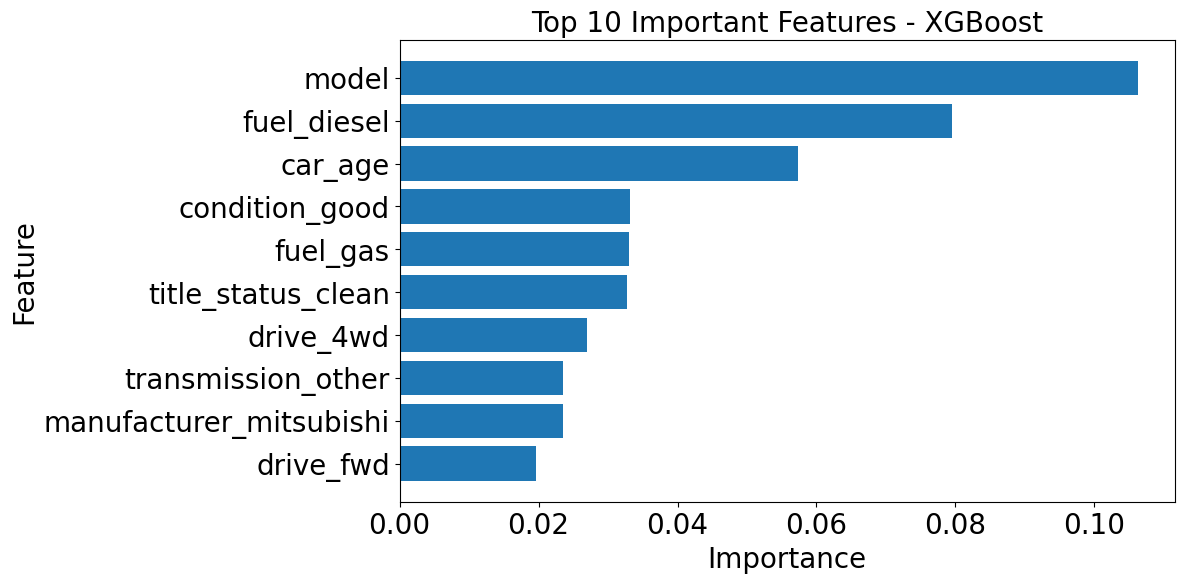

In [191]:
top10 = importance_df.head(10).sort_values(by='importance')

plt.figure(figsize=(10, 6))
plt.barh(top10['feature'], top10['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features - XGBoost')
plt.show()

**model**

Car model is the most important feature in the model. Since it is encoded using target encoding, it reflects the average price of each car model, meaning some models are consistently more expensive than others. This is consistent with prior research showing that vehicle type and brand significantly influence used car prices (Chen & Guestrin, 2016).

**fuel_diesel**

Fuel type plays an important role in price prediction. Diesel vehicles show a noticeable impact on the model, indicating that fuel type is an important factor when estimating car prices. Previous studies have also found that fuel type affects vehicle valuation due to differences in efficiency and market demand (Breiman, 2001).

**car_age**

Car age is a key factor in determining price. Older cars tend to have lower values, showing the effect of depreciation over time. This aligns with general findings in the literature that vehicle age is one of the strongest predictors of used car price due to depreciation (Chen & Guestrin, 2016).

**condition_good**

Vehicle condition has a clear influence on price. Cars in good condition are more valuable and more attractive to buyers. This reflects common findings that physical condition directly impacts resale value (Pedregosa et al., 2011).

**fuel_gas**

Gas-powered vehicles also contribute to price variation, further confirming that fuel type is an important attribute in the model, as supported by prior machine learning studies on vehicle pricing (Breiman, 2001).

**title_status_clean**

Cars with a clean title tend to have higher value and are more trusted in the market, making this an important feature in price prediction. This aligns with real-world observations that legal and ownership status affects buyer confidence.

**drive_4wd**

Drive type affects the price, and 4WD vehicles are often valued differently due to their performance and suitability for certain driving conditions. This suggests that functional attributes of vehicles influence pricing decisions.

**transmission_other**

Transmission type also impacts the model, suggesting that different transmission systems may influence buyer preferences and pricing, as supported in predictive modeling studies (Pedregosa et al., 2011).

**manufacturer_mitsubishi**

Manufacturer has some influence on price. Certain brands contribute to price differences, although the impact is smaller compared to core features such as age and usage.

**drive_fwd**

Front-wheel drive vehicles also play a role in price variation, showing that drivetrain configuration is a relevant factor in pricing.

## **Conclusions**

The model performs pretty well, with an R2 of 0.88, meaning it explains most of the variation in car prices. The MAE is 0.20, indicating that the average prediction error is relatively small. The RMSE is 0.35, which is slightly higher than the MAE and suggests that there are some larger errors, but not many.

When converted back to dollars, the MAE is about 2,922.87 and the RMSE is 5,023.53, which are both reasonable and show that the model provides fairly accurate predictions.

The feature importance results show that car model is the most important factor, followed by fuel type, car age, and condition. This suggests that both vehicle characteristics and usage-related factors are key in predicting used car prices.

## **References**

1. Reese, A. (n.d.). *Craigslist cars and trucks data* [Data set]. Kaggle. https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

2. Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*. https://doi.org/10.1145/2939672.2939785

3. Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

4. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
